<a href="https://colab.research.google.com/github/Schumau/DS/blob/main/Evaluacion_Integ_Contep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análisis Costo-Volumen-Utilidad (CVU)
## Caso: Conteplat S.A.

**Industria:** Fabricación de preformas PET de uso alimentario
**Producto:** preformas PET
**Ubicación:** Parque Industrial de Abasto, Buenos Aires

---

Este notebook resuelve el caso de evaluación integradora de la materia *Economía y Costos* (UTN-FRLP), aplicando un análisis CVU completo con Python: clasificación de costos, punto de equilibrio, margen de seguridad, punto de cierre y análisis de sensibilidad sobre tres escenarios de negocio.

**Autor:** Mauro
**Stack:** Python · pandas · matplotlib · numpy

---


## 0. Setup e imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Estilo visual
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paleta de colores del proyecto
COLOR_AZUL = '#1565C0'
COLOR_CIAN = '#00BCD4'
COLOR_VERDE = '#2E7D32'
COLOR_ROJO = '#C62828'
COLOR_AMARILLO = '#F9A825'
COLOR_GRIS = '#607D8B'

def formato_pesos(x, pos=None):
    return f'${x:,.0f}'.replace(',', '.')

pd.options.display.float_format = '{:,.2f}'.format
print("Librerías cargadas correctamente ✅")


Librerías cargadas correctamente ✅


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Datos base del problema

| Parámetro | Valor |
|---|---|
| Capacidad normal de planta | 5.000 unidades/mes |
| Producción y ventas del último mes | 3.500 unidades |
| Precio de venta unitario | $8.400 |
| Tasa de impuesto a las ganancias | 35% |

**Supuesto clave:** producción = ventas (sin variación de inventarios). Los costos y gastos variables son directamente proporcionales al volumen.


In [ ]:
# Parámetros generales
CAPACIDAD_NORMAL = 5000
UNIDADES = 3500
PRECIO_VENTA = 8400
TASA_IMPUESTO = 0.35

print(f"Capacidad normal:     {CAPACIDAD_NORMAL:,} uds/mes".replace(',', '.'))
print(f"Producción/Ventas:    {UNIDADES:,} uds/mes".replace(',', '.'))
print(f"Precio de venta:      ${PRECIO_VENTA:,}".replace(',', '.'))
print(f"Tasa de impuesto:     {TASA_IMPUESTO:.0%}")


Capacidad normal:     5.000 uds/mes
Producción/Ventas:    3.500 uds/mes
Precio de venta:      $8.400
Tasa de impuesto:     35%


## 2. Parte I — Clasificación de costos

Clasificamos cada concepto del estado de costos según:
- **Comportamiento:** Fijo (F) o Variable (V)
- **Relación con el producto:** Directo (D) o Indirecto (I)


In [ ]:
costos = pd.DataFrame([
    # Costos de producción
    {"concepto": "Resina de polipropileno",        "monto": 7_000_000, "comportamiento": "Variable", "relacion": "Directo",   "categoria": "Producción"},
    {"concepto": "Pigmentos y aditivos",            "monto": 1_050_000, "comportamiento": "Variable", "relacion": "Directo",   "categoria": "Producción"},
    {"concepto": "Mano de obra directa",            "monto": 3_500_000, "comportamiento": "Variable", "relacion": "Directo",   "categoria": "Producción"},
    {"concepto": "Energía eléctrica de producción", "monto":   700_000, "comportamiento": "Variable", "relacion": "Directo",   "categoria": "Producción"},
    {"concepto": "Suministros de fábrica",          "monto":   350_000, "comportamiento": "Variable",     "relacion": "Indirecto", "categoria": "Producción"},
    {"concepto": "Depreciación maquinaria",         "monto":   600_000, "comportamiento": "Fijo",     "relacion": "Indirecto", "categoria": "Producción"},
    {"concepto": "Alquiler galpón de producción",   "monto": 1_200_000, "comportamiento": "Fijo",     "relacion": "Indirecto", "categoria": "Producción"},
    {"concepto": "Sueldo jefe de producción",       "monto":   800_000, "comportamiento": "Fijo",     "relacion": "Indirecto", "categoria": "Producción"},
    {"concepto": "Seguro de planta y maquinaria",   "monto":   250_000, "comportamiento": "Fijo",     "relacion": "Indirecto", "categoria": "Producción"},
    {"concepto": "Amortización de moldes",          "monto":   200_000, "comportamiento": "Fijo",     "relacion": "Indirecto", "categoria": "Producción"},
    # Gastos de administración y ventas
    {"concepto": "Comisiones a vendedores",         "monto": 1_400_000, "comportamiento": "Variable", "relacion": "Directo",   "categoria": "Admin/Ventas"},
    {"concepto": "Embalaje y flete de entrega",     "monto":   700_000, "comportamiento": "Variable", "relacion": "Directo",   "categoria": "Admin/Ventas"},
    {"concepto": "Sueldos de administración",       "monto":   900_000, "comportamiento": "Fijo",     "relacion": "Indirecto", "categoria": "Admin/Ventas"},
    {"concepto": "Alquiler de oficinas",            "monto":   300_000, "comportamiento": "Fijo",     "relacion": "Indirecto", "categoria": "Admin/Ventas"},
    {"concepto": "Servicios administrativos",       "monto":   150_000, "comportamiento": "Fijo",     "relacion": "Indirecto", "categoria": "Admin/Ventas"},
    {"concepto": "Publicidad institucional",        "monto":   250_000, "comportamiento": "Fijo",     "relacion": "Indirecto", "categoria": "Admin/Ventas"},
])

# Marcamos cuáles costos fijos son "hundidos" (no implican erogación de efectivo)
costos["es_hundido"] = costos["concepto"].isin(["Depreciación maquinaria", "Amortización de moldes"])

costos.style.format({"monto": formato_pesos})


,concepto,monto,comportamiento,relacion,categoria,es_hundido
0,Resina de polipropileno,$7.000.000,Variable,Directo,Producción,False
1,Pigmentos y aditivos,$1.050.000,Variable,Directo,Producción,False
2,Mano de obra directa,$3.500.000,Variable,Directo,Producción,False
3,Energía eléctrica de producción,$700.000,Variable,Directo,Producción,False
4,Suministros de fábrica,$350.000,Variable,Indirecto,Producción,False
5,Depreciación maquinaria,$600.000,Fijo,Indirecto,Producción,True
6,Alquiler galpón de producción,$1.200.000,Fijo,Indirecto,Producción,False
7,Sueldo jefe de producción,$800.000,Fijo,Indirecto,Producción,False
8,Seguro de planta y maquinaria,$250.000,Fijo,Indirecto,Producción,False
9,Amortización de moldes,$200.000,Fijo,Indirecto,Producción,True


In [ ]:
# Costo variable unitario (CVu)
variables = costos[costos["comportamiento"] == "Variable"].copy()
variables["unitario"] = variables["monto"] / UNIDADES

CVU = variables["unitario"].sum()
print("Detalle del costo variable unitario:")
display(variables[["concepto", "monto", "unitario"]].style.format({"monto": formato_pesos, "unitario": formato_pesos}))
print(f"\n➡️  Costo Variable Unitario (CVu) = ${CVU:,.0f}".replace(',', '.'))


Detalle del costo variable unitario:


,concepto,monto,unitario
0,Resina de polipropileno,$7.000.000,$2.000
1,Pigmentos y aditivos,$1.050.000,$300
2,Mano de obra directa,$3.500.000,$1.000
3,Energía eléctrica de producción,$700.000,$200
4,Suministros de fábrica,$350.000,$100
10,Comisiones a vendedores,$1.400.000,$400
11,Embalaje y flete de entrega,$700.000,$200



➡️  Costo Variable Unitario (CVu) = $4.200


In [ ]:
# Costo fijo total y desagregación en vivos / hundidos
fijos = costos[costos["comportamiento"] == "Fijo"].copy()

CF_TOTAL = fijos["monto"].sum()
CF_HUNDIDOS = fijos.loc[fijos["es_hundido"], "monto"].sum()
CF_VIVOS = CF_TOTAL - CF_HUNDIDOS

print(f"Costo Fijo Total (CF):        ${CF_TOTAL:,.0f}".replace(',', '.'))
print(f"  - Costos fijos hundidos:    ${CF_HUNDIDOS:,.0f}  (depreciación + amortización)".replace(',', '.'))
print(f"  - Costos fijos vivos (Fv):  ${CF_VIVOS:,.0f}".replace(',', '.'))


Costo Fijo Total (CF):        $4.650.000
  - Costos fijos hundidos:    $800.000  (depreciación + amortización)
  - Costos fijos vivos (Fv):  $3.850.000


### 📊 Composición visual de costos: Fijo vs. Variable

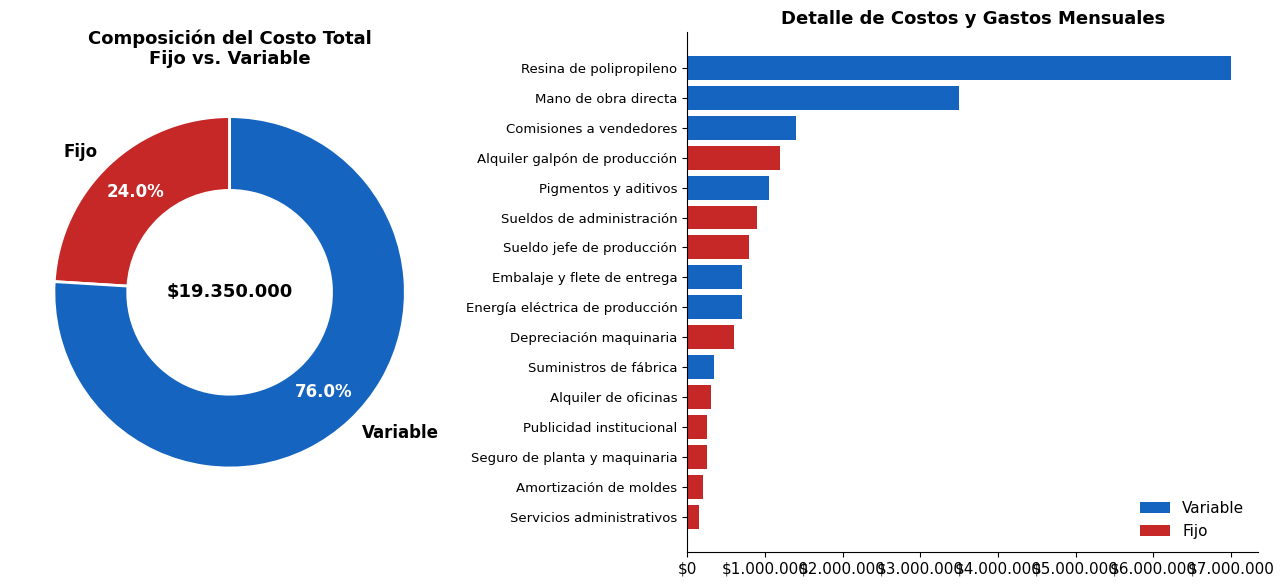

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={'width_ratios': [1, 1.3]})

totales = costos.groupby("comportamiento")["monto"].sum()
colors_donut = [COLOR_ROJO, COLOR_AZUL]
wedges, texts, autotexts = axes[0].pie(
    totales.values, labels=totales.index, autopct='%1.1f%%',
    colors=colors_donut, startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(12)
axes[0].set_title("Composición del Costo Total\nFijo vs. Variable", fontsize=13, fontweight='bold')
axes[0].text(0, 0, f"${totales.sum():,.0f}".replace(',', '.'), ha='center', va='center', fontsize=13, fontweight='bold')

costos_sorted = costos.sort_values("monto", ascending=True)
bar_colors = costos_sorted["comportamiento"].map({"Variable": COLOR_AZUL, "Fijo": COLOR_ROJO})
axes[1].barh(costos_sorted["concepto"], costos_sorted["monto"], color=bar_colors)
axes[1].set_title("Detalle de Costos y Gastos Mensuales", fontsize=13, fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(formato_pesos))
axes[1].tick_params(axis='y', labelsize=9.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLOR_AZUL, label='Variable'), Patch(facecolor=COLOR_ROJO, label='Fijo')]
axes[1].legend(handles=legend_elements, loc='lower right', frameon=False)

plt.tight_layout()
plt.show()

**💡 Nota conceptual:** la depreciación de maquinaria y la amortización de moldes se clasifican como costos fijos porque no dependen del volumen producido — se generan por el método de línea recta en función del tiempo. Como no implican una salida de efectivo en el período, se consideran *costos hundidos* y se excluyen del cálculo del punto de cierre.

## 3. Parte II — Margen de contribución y punto de equilibrio

In [ ]:
MCU = PRECIO_VENTA - CVU
RMC = MCU / PRECIO_VENTA

print(f"Precio de Venta Unitario (PVu):         ${PRECIO_VENTA:,.0f}".replace(',', '.'))
print(f"Costo Variable Unitario (CVu):          ${CVU:,.0f}".replace(',', '.'))
print(f"Margen de Contribución Unitario (MCu):  ${MCU:,.0f}".replace(',', '.'))
print(f"Razón de Margen de Contribución (RMC):  {RMC:.2%}")


Precio de Venta Unitario (PVu):         $8.400
Costo Variable Unitario (CVu):          $4.200
Margen de Contribución Unitario (MCu):  $4.200
Razón de Margen de Contribución (RMC):  50.00%


### 📊 Waterfall: del precio de venta al margen de contribución

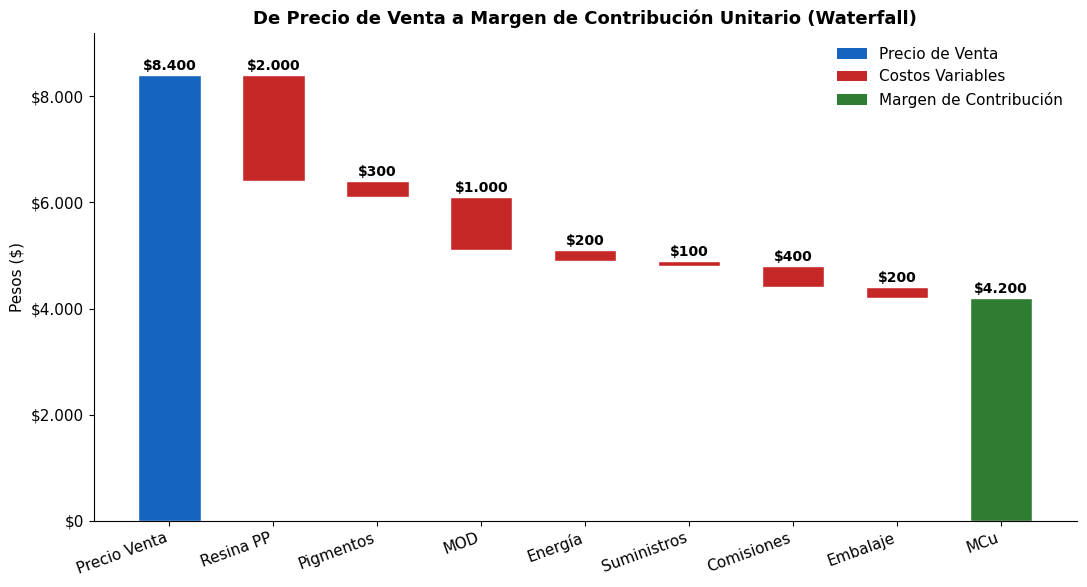

In [ ]:
CVU_DETALLE = [
    ("Precio Venta", 8400, "total"),
    ("Resina PP", -2000, "cost"),
    ("Pigmentos", -300, "cost"),
    ("MOD", -1000, "cost"),
    ("Energía", -200, "cost"),
    ("Suministros", -100, "cost"),
    ("Comisiones", -400, "cost"),
    ("Embalaje", -200, "cost"),
    ("MCu", None, "result"),
]

fig, ax = plt.subplots(figsize=(11, 6))
running = 0
x_labels, bottoms, heights, colors = [], [], [], []

for label, val, kind in CVU_DETALLE:
    x_labels.append(label)
    if kind == "total":
        bottoms.append(0); heights.append(val); colors.append(COLOR_AZUL); running = val
    elif kind == "cost":
        bottoms.append(running + val); heights.append(-val); colors.append(COLOR_ROJO); running += val
    elif kind == "result":
        bottoms.append(0); heights.append(running); colors.append(COLOR_VERDE)

ax.bar(x_labels, heights, bottom=bottoms, color=colors, width=0.6, edgecolor='white', linewidth=1)

for i, (label, val, kind) in enumerate(CVU_DETALLE):
    display_val = val if val is not None else running
    ax.text(i, bottoms[i] + heights[i] + 100, f"${abs(display_val):,.0f}".replace(',', '.'), ha='center', fontsize=10, fontweight='bold')

ax.set_title("De Precio de Venta a Margen de Contribución Unitario (Waterfall)", fontsize=13, fontweight='bold')
ax.set_ylabel("Pesos ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formato_pesos))
ax.set_ylim(0, 9200)
plt.xticks(rotation=20, ha='right')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_AZUL, label='Precio de Venta'),
    Patch(facecolor=COLOR_ROJO, label='Costos Variables'),
    Patch(facecolor=COLOR_VERDE, label='Margen de Contribución'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
PE_UNIDADES = CF_TOTAL / MCU
PE_PESOS = CF_TOTAL / RMC

print(f"Punto de Equilibrio (unidades):  {PE_UNIDADES:,.0f} uds".replace(',', '.'))
print(f"Punto de Equilibrio (pesos):     ${PE_PESOS:,.0f}".replace(',', '.'))

PUNTO_CIERRE_UDS = CF_VIVOS / MCU
PUNTO_CIERRE_PESOS = PUNTO_CIERRE_UDS * PRECIO_VENTA

print(f"\nPunto de Cierre (unidades):      {PUNTO_CIERRE_UDS:,.0f} uds".replace(',', '.'))
print(f"Punto de Cierre (pesos):         ${PUNTO_CIERRE_PESOS:,.0f}".replace(',', '.'))


Punto de Equilibrio (unidades):  1.107 uds
Punto de Equilibrio (pesos):     $9.300.000

Punto de Cierre (unidades):      917 uds
Punto de Cierre (pesos):         $7.700.000


### 📈 Gráfico CVU: Ingresos, Costo Total y Punto de Equilibrio

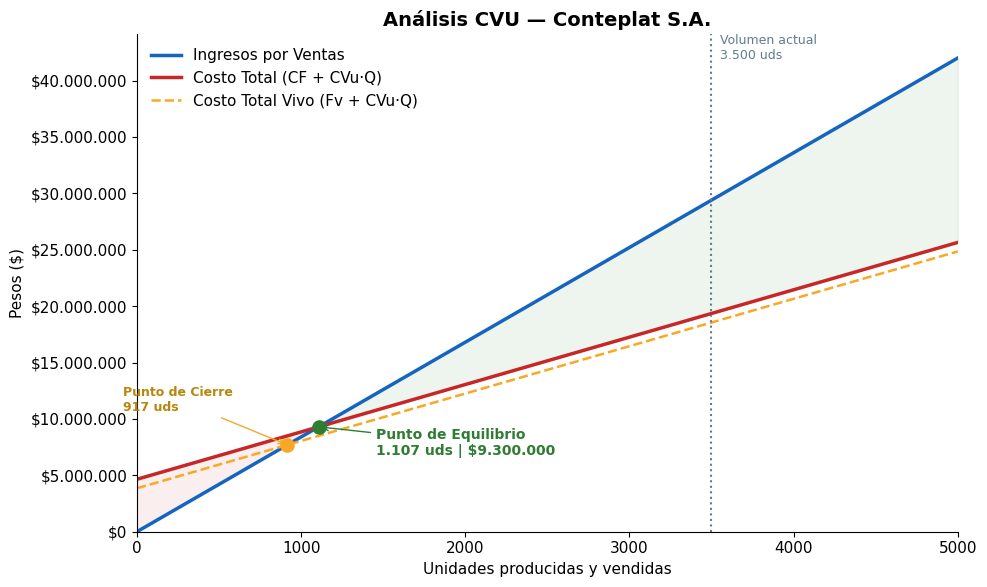

In [ ]:
rango_uds = np.linspace(0, CAPACIDAD_NORMAL, 500)
ingresos = rango_uds * PRECIO_VENTA
costo_total = CF_TOTAL + rango_uds * CVU
costo_vivo_total = CF_VIVOS + rango_uds * CVU

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(rango_uds, ingresos, color=COLOR_AZUL, linewidth=2.5, label="Ingresos por Ventas")
ax.plot(rango_uds, costo_total, color=COLOR_ROJO, linewidth=2.5, label="Costo Total (CF + CVu·Q)")
ax.plot(rango_uds, costo_vivo_total, color=COLOR_AMARILLO, linewidth=1.8, linestyle="--", label="Costo Total Vivo (Fv + CVu·Q)")

# Zona de pérdida y ganancia
ax.fill_between(rango_uds, ingresos, costo_total, where=(ingresos < costo_total), color=COLOR_ROJO, alpha=0.08)
ax.fill_between(rango_uds, ingresos, costo_total, where=(ingresos >= costo_total), color=COLOR_VERDE, alpha=0.08)

# Punto de equilibrio
ax.scatter([PE_UNIDADES], [PE_PESOS], color=COLOR_VERDE, s=90, zorder=5)
ax.annotate(f"Punto de Equilibrio\n{PE_UNIDADES:,.0f} uds | ${PE_PESOS:,.0f}".replace(',', '.'),
            xy=(PE_UNIDADES, PE_PESOS), xytext=(PE_UNIDADES + 350, PE_PESOS - 2_500_000),
            fontsize=10, color=COLOR_VERDE, fontweight='bold',
            arrowprops=dict(arrowstyle="->", color=COLOR_VERDE))

# Punto de cierre
ax.scatter([PUNTO_CIERRE_UDS], [PUNTO_CIERRE_PESOS], color=COLOR_AMARILLO, s=90, zorder=5)
ax.annotate(f"Punto de Cierre\n{PUNTO_CIERRE_UDS:,.0f} uds".replace(',', '.'),
            xy=(PUNTO_CIERRE_UDS, PUNTO_CIERRE_PESOS), xytext=(PUNTO_CIERRE_UDS - 1000, PUNTO_CIERRE_PESOS + 3_000_000),
            fontsize=9, color="#B8860B", fontweight='bold',
            arrowprops=dict(arrowstyle="->", color=COLOR_AMARILLO))

# Volumen actual
ax.axvline(UNIDADES, color=COLOR_GRIS, linestyle=":", linewidth=1.5)
ax.text(UNIDADES + 50, ax.get_ylim()[1]*0.95, f"Volumen actual\n{UNIDADES:,.0f} uds".replace(',', '.'),
        fontsize=9, color=COLOR_GRIS)

ax.set_xlabel("Unidades producidas y vendidas")
ax.set_ylabel("Pesos ($)")
ax.set_title("Análisis CVU — Conteplat S.A.", fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formato_pesos))
ax.legend(loc="upper left", frameon=False)
ax.set_xlim(0, CAPACIDAD_NORMAL)
ax.set_ylim(0, max(ingresos)*1.05)

plt.tight_layout()
plt.show()


## 4. Estados de resultados por costeo variable

Construimos el estado de resultados (a) en el punto de equilibrio, para verificar utilidad operativa cero, y (b) para el volumen necesario para alcanzar una utilidad neta objetivo de **$3.510.000**.

In [ ]:
def estado_resultados(unidades, precio, cvu, cf, tasa_imp):
    ventas = unidades * precio
    cv = unidades * cvu
    mc = ventas - cv
    utilidad_operativa = mc - cf
    impuesto = max(utilidad_operativa, 0) * tasa_imp
    utilidad_neta = utilidad_operativa - impuesto
    return pd.Series({
        "Unidades": unidades,
        "Ventas": ventas,
        "Costos Variables": -cv,
        "Margen de Contribución": mc,
        "Costos Fijos": -cf,
        "Utilidad Operativa": utilidad_operativa,
        "Impuesto Ganancias (35%)": -impuesto,
        "Utilidad Neta": utilidad_neta
    })

er_equilibrio = estado_resultados(PE_UNIDADES, PRECIO_VENTA, CVU, CF_TOTAL, TASA_IMPUESTO)
print("Estado de Resultados — Punto de Equilibrio")
display(er_equilibrio.apply(formato_pesos))


Estado de Resultados — Punto de Equilibrio


,0
Unidades,$1.107
Ventas,$9.300.000
Costos Variables,$-4.650.000
Margen de Contribución,$4.650.000
Costos Fijos,$-4.650.000
Utilidad Operativa,$0
Impuesto Ganancias (35%),$-0
Utilidad Neta,$0


In [ ]:
UTILIDAD_NETA_OBJETIVO = 3_510_000
utilidad_bruta_objetivo = UTILIDAD_NETA_OBJETIVO / (1 - TASA_IMPUESTO)
Q_OBJETIVO = (CF_TOTAL + utilidad_bruta_objetivo) / MCU

print(f"Utilidad bruta necesaria: ${utilidad_bruta_objetivo:,.0f}".replace(',', '.'))
print(f"Unidades necesarias:      {Q_OBJETIVO:,.0f} uds\n".replace(',', '.'))

er_objetivo = estado_resultados(Q_OBJETIVO, PRECIO_VENTA, CVU, CF_TOTAL, TASA_IMPUESTO)
print("Estado de Resultados — Utilidad Neta Objetivo")
display(er_objetivo.apply(formato_pesos))


Utilidad bruta necesaria: $5.400.000
Unidades necesarias:      2.393 uds

Estado de Resultados — Utilidad Neta Objetivo


,0
Unidades,$2.393
Ventas,$20.100.000
Costos Variables,$-10.050.000
Margen de Contribución,$10.050.000
Costos Fijos,$-4.650.000
Utilidad Operativa,$5.400.000
Impuesto Ganancias (35%),$-1.890.000
Utilidad Neta,$3.510.000


## 5. Margen de seguridad (proyección de 4.200 unidades)

In [ ]:
VENTAS_PROYECTADAS = 4200

MS_UNIDADES = VENTAS_PROYECTADAS - PE_UNIDADES
MS_PESOS = MS_UNIDADES * PRECIO_VENTA
RMS = MS_UNIDADES / VENTAS_PROYECTADAS

print(f"Ventas proyectadas:               {VENTAS_PROYECTADAS:,.0f} uds".replace(',', '.'))
print(f"Margen de Seguridad (unidades):   {MS_UNIDADES:,.0f} uds".replace(',', '.'))
print(f"Margen de Seguridad (pesos):      ${MS_PESOS:,.0f}".replace(',', '.'))
print(f"Razón de Margen de Seguridad:     {RMS:.1%}")


Ventas proyectadas:               4.200 uds
Margen de Seguridad (unidades):   3.093 uds
Margen de Seguridad (pesos):      $25.980.000
Razón de Margen de Seguridad:     73.6%


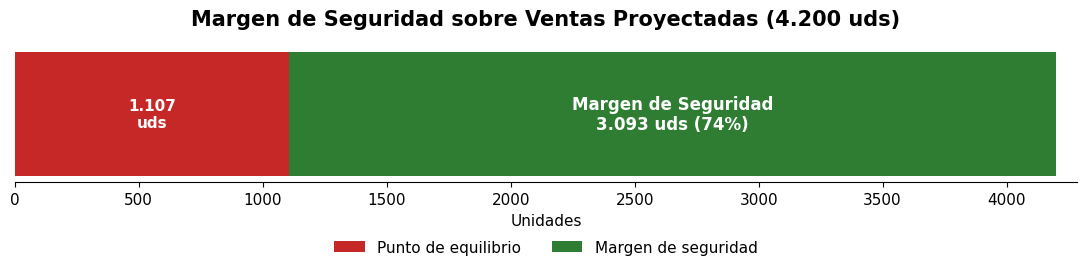

In [ ]:
fig, ax = plt.subplots(figsize=(11, 3.2))

ax.barh([0], [PE_UNIDADES], color=COLOR_ROJO, height=0.45, label="Punto de equilibrio")
ax.barh([0], [MS_UNIDADES], left=[PE_UNIDADES], color=COLOR_VERDE, height=0.45, label="Margen de seguridad")

ax.text(PE_UNIDADES/2, 0, f"{PE_UNIDADES:,.0f}\nuds".replace(',', '.'), ha='center', va='center', color='white', fontweight='bold', fontsize=11)
ax.text(PE_UNIDADES + MS_UNIDADES/2, 0, f"Margen de Seguridad\n{MS_UNIDADES:,.0f} uds ({RMS:.0%})".replace(',', '.'), ha='center', va='center', color='white', fontweight='bold', fontsize=12)

ax.set_yticks([])
ax.set_xlabel("Unidades", fontsize=11)
ax.set_title("Margen de Seguridad sobre Ventas Proyectadas (4.200 uds)", fontsize=15, fontweight='bold', pad=15)
ax.set_xlim(0, VENTAS_PROYECTADAS * 1.02)
ax.spines['left'].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.32), ncol=2, frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

**Interpretación:** la empresa puede resignar hasta un **72,3%** de sus ventas proyectadas antes de entrar en zona de pérdida. Es un margen de seguridad alto, indicativo de bajo riesgo operativo al nivel de actividad analizado.

## 6. Parte III — Análisis de sensibilidad: tres escenarios

| Escenario | Cambio propuesto |
|---|---|
| **A** | +800 uds/mes de un cliente nuevo, con 10% de descuento sobre precio de lista |
| **B** | Nueva inyectora automática: CVu -$300, CF +$500.000 |
| **C** | Aumento de precio +5%, con caída de volumen a 3.200 uds |


In [ ]:
def evaluar_escenario(nombre, unidades, precio, cvu, cf):
    mcu = precio - cvu
    pe = cf / mcu
    utilidad_operativa = (unidades - pe) * mcu
    return {
        "Escenario": nombre,
        "Volumen (uds)": unidades,
        "Precio": precio,
        "CVu": cvu,
        "MCu": mcu,
        "CF": cf,
        "Nuevo PE (uds)": pe,
        "Utilidad Operativa": utilidad_operativa
    }
VENTAS_ESC_A = ((UNIDADES * PRECIO_VENTA) + (800 * PRECIO_VENTA * 0.90))/4300

UNIDADES_ESC_A = UNIDADES + 800

escenarios = pd.DataFrame([
    evaluar_escenario("Situación Actual", UNIDADES, PRECIO_VENTA, CVU, CF_TOTAL),
    evaluar_escenario("A - Cliente nuevo (10% desc.)", UNIDADES_ESC_A, VENTAS_ESC_A, CVU, CF_TOTAL),
    evaluar_escenario("B - Nueva inyectora", UNIDADES, PRECIO_VENTA, CVU - 300, CF_TOTAL + 500_000),
    evaluar_escenario("C - Precio +5%, vol. -300", 3200, PRECIO_VENTA * 1.05, CVU, CF_TOTAL),
])

escenarios.set_index("Escenario").style.format({
    "Precio": formato_pesos, "CVu": formato_pesos, "MCu": formato_pesos, "CF": formato_pesos,
    "Nuevo PE (uds)": "{:,.0f}", "Utilidad Operativa": formato_pesos, "Volumen (uds)": "{:,.0f}"
})


,Volumen (uds),Precio,CVu,MCu,CF,Nuevo PE (uds),Utilidad Operativa
Escenario,,,,,,,
Situación Actual,"3,500",$8.400,$4.200,$4.200,$4.650.000,"1,107",$10.050.000
A - Cliente nuevo (10% desc.),"4,300",$8.244,$4.200,$4.044,$4.650.000,"1,150",$12.738.000
B - Nueva inyectora,"3,500",$8.400,$3.900,$4.500,$5.150.000,"1,144",$10.600.000
"C - Precio +5%, vol. -300","3,200",$8.820,$4.200,$4.620,$4.650.000,"1,006",$10.134.000


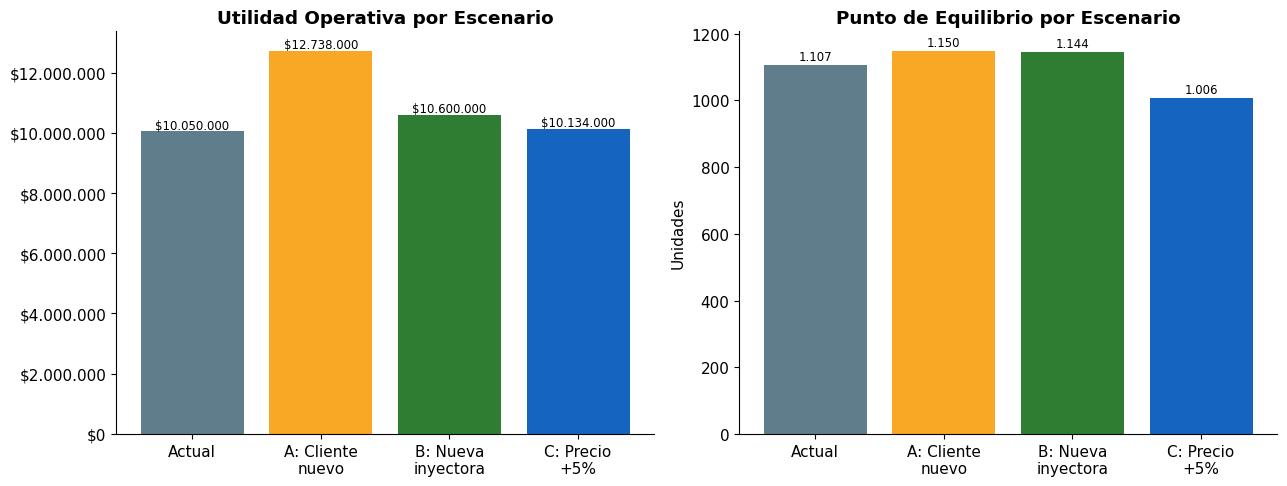

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colores_esc = [COLOR_GRIS, COLOR_AMARILLO, COLOR_VERDE, COLOR_AZUL]
nombres_cortos = ["Actual", "A: Cliente\nnuevo", "B: Nueva\ninyectora", "C: Precio\n+5%"]

# Utilidad operativa
axes[0].bar(nombres_cortos, escenarios["Utilidad Operativa"], color=colores_esc)
axes[0].set_title("Utilidad Operativa por Escenario", fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(formato_pesos))
for i, v in enumerate(escenarios["Utilidad Operativa"]):
    axes[0].text(i, v + 80000, f"${v:,.0f}".replace(',', '.'), ha='center', fontsize=8.5)

# Nuevo punto de equilibrio
axes[1].bar(nombres_cortos, escenarios["Nuevo PE (uds)"], color=colores_esc)
axes[1].set_title("Punto de Equilibrio por Escenario", fontweight='bold')
axes[1].set_ylabel("Unidades")
for i, v in enumerate(escenarios["Nuevo PE (uds)"]):
    axes[1].text(i, v + 15, f"{v:,.0f}".replace(',', '.'), ha='center', fontsize=8.5)

plt.tight_layout()
plt.show()


### ✅ Recomendación

El **Escenario B (nueva inyectora automática)** es el más conveniente:

- Genera la **mayor utilidad operativa absoluta** entre los tres escenarios.
- No depende de ceder margen por unidad (a diferencia del Escenario A) ni de una caída incierta de demanda (a diferencia del Escenario C).
- La reducción del CVu es una **mejora estructural y permanente**, escalable a futuros aumentos de volumen.
- Mantiene un margen de seguridad amplio frente al nuevo punto de equilibrio (1.196 uds vs. 3.500 uds actuales).


## 7. Resumen ejecutivo (KPIs)

In [ ]:
kpis = {
    "CVu": f"${CVU:,.0f}".replace(',', '.'),
    "MCu": f"${MCU:,.0f}".replace(',', '.'),
    "RMC": f"{RMC:.2%}",
    "Punto de Equilibrio": f"{PE_UNIDADES:,.0f} uds".replace(',', '.'),
    "Punto de Cierre": f"{PUNTO_CIERRE_UDS:,.0f} uds".replace(',', '.'),
    "Margen de Seguridad (4.200 uds)": f"{RMS:.1%}",
    "Unidades para utilidad objetivo": f"{Q_OBJETIVO:,.0f} uds".replace(',', '.'),
    "Escenario recomendado": "A – Nuevo cliente",
}

for k, v in kpis.items():
    print(f"{k:.<40} {v}")


CVu..................................... $4.200
MCu..................................... $4.200
RMC..................................... 50.00%
Punto de Equilibrio..................... 1.107 uds
Punto de Cierre......................... 917 uds
Margen de Seguridad (4.200 uds)......... 73.6%
Unidades para utilidad objetivo......... 2.393 uds
Escenario recomendado................... A – Nuevo cliente


---

## 8. Conclusión

El caso de Conteplat S.A. muestra una estructura de costos con **alta proporción de margen de contribución (50%)**, lo que le da a la empresa flexibilidad para absorber variaciones de volumen sin comprometer la rentabilidad. El nivel de actividad actual (3.500 uds) está muy por encima del punto de equilibrio (1.107 uds), generando un margen de seguridad sólido.

Entre los escenarios evaluados, integrar a **un nuevo cliente que solicite un lote adicional con un pequeño descuento** ofrece la mejor combinación de rentabilidad y seguridad operativa, al alcanzar la mayor utilidad operativa ($12.738.000) y el mayor margen de seguridad (74,3%). Además, permite aprovechar la capacidad ociosa existente sin requerir inversiones adicionales ni incrementos en los costos fijos, generando un crecimiento inmediato de los resultados de la empresa. Por su parte, el Escenario B puede considerarse una alternativa estratégica de mediano plazo, ya que mejora la eficiencia productiva y la estructura de costos, aunque requiere una inversión inicial y presenta un menor margen de seguridad.

---
*Universidad Tecnológica Nacional – FRLP · Ingeniería Industrial · Economía y Costos*
